In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import random

from modules import background_model, ModelDataSet, SequenceRepresentation

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

2025-06-12 15:44:52.766876: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 15:44:52.772573: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 15:44:52.837880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-12 15:44:53.886916: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
N = 10
seqlen = 1000
tile_size = 100
batch_size = 2
K = 1

In [3]:
def generate_data(model: np.ndarray, N: int, seqlen: int, tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=3) # DO NOT USE TOO LARGE tile_size, as there happens a multiplication along that axis
    assert ''.join(data.alphabet) == "ACGT", f"Alphabet must be ACGT for this model, not {data.alphabet}."
    return data

In [4]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [5]:
data1 = generate_data(ground_truth_1, N, tile_size, batch_size, seqlen)
model1 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q1_init = model1.getQ()
m1_init = model1.getM()

2025-06-12 15:44:54,973 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 15:44:54,988 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)


In [6]:
data1.getRawData()

[[['GACAGGTACAAGAAGGAGTATGCATCAATGTGGTCGTGTGGAACAAACGCCACTGGAGACTGGGTTAACCATTCGCTCCAGCGTCATGAAAGTCACTGTT',
   'AACAGTGACTTTCATGACGCTGGAGCGAATGGTTAACCCAGTCTCCAGTGGCGTTTGTTCCACACGACCACATTGATGCATACTCCTTCTTGTACCTGTC']],
 [['AGGGCGACCTTCGATTCGGATGTGACATTTCATTACATTACGCTCAGGACTGCGAACGAAAGATTAAGAATGCTTAACCCGGTACCTAACCCATCTGATT',
   'AATCAGATGGGTTAGGTACCGGGTTAAGCATTCTTAATCTTTCGTTCGCAGTCCTGAGCGTAATGTAATGAAATGTCACATCCGAATCGAAGGTCGCCCT']],
 [['TTTACACACTCTCCTTGGACTGGGAGGTATAAGGAATAGGCGGTAGACGCCTACTTAACTTTCATGGTGATCGTAAAGCGGAGCCTTACCATGCGGCAAT',
   'ATTGCCGCATGGTAAGGCTCCGCTTTACGATCACCATGAAAGTTAAGTAGGCGTCTACCGCCTATTCCTTATACCTCCCAGTCCAAGGAGAGTGTGTAAA']],
 [['TGTGAACTTTTAAATTCGATTTTTAGCTTTTCTATTATCCTAAACTTCGCTGTATATCACGCGGCGCGATGGGGCAGCCTGCCCCCACTGTGCGACCGGC',
   'GCCGGTCGCACAGTGGGGGCAGGCTGCCCCATCGCGCCGCGTGATATACAGCGAAGTTTAGGATAATAGAAAAGCTAAAAATCGAATTTAAAAGTTCACA']],
 [['CACTTAAGGCTTGAAAACTACGAGCAGATTACATGAATCTGTGTTGGGTGTGCCAGTGGCACCCGAAGGACGCACTGGTTCACTTTCGGGAACACGCACA',
   'TGTGCGTGTTCCCGAAAGTGAACCA

In [7]:
np.log(1e-10)

-23.025850929940457

In [8]:
losses1 = model1.train(data1, lr=0.01, epochs=50)

2025-06-12 15:44:55,050 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 15:44:56.831888: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:44:56,834 - INFO - [background_model.train] >>> epoch     0 mean loss = 23.0259, time: 1.78s
2025-06-12 15:44:57.446781: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:44:58.072023: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:44:58.670094: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:44:59.241466: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:44:59.796567: W tensorflow

2025-06-12 15:45:24,606 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-12 15:45:24,608 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-12 15:45:24,613 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-06-12 15:45:24,615 - DEBUG - findfont: score(FontEntry(fname='/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-06-12 15:45:24,616 - DEBUG - findfont: score(FontEntry(fname='/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/cmsy10.ttf', name='cmsy10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-06-12 15:45:24,617 - DEBUG - findfont: score(FontEntry(fname='/

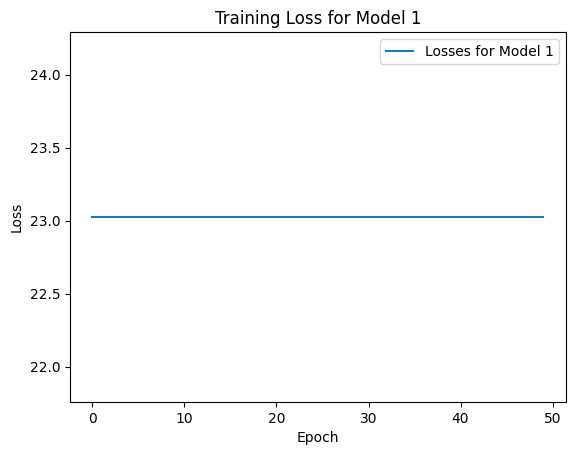

In [9]:
# plot losses1
plt.plot(losses1, label='Losses for Model 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 1')
plt.legend()
plt.show()

In [10]:
print(Q1_init.numpy())
print()
print(m1_init.numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [11]:
print(model1.getQ().numpy())
print()
print(model1.getM().numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [12]:
print(ground_truth_1)

[0.25 0.25 0.25 0.25]


---

2025-06-12 15:45:25,022 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 15:45:25,033 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-12 15:45:25,041 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 15:45:25.532718: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:25,535 - INFO - [background_model.train] >>> epoch     0 mean loss = 23.0259, time: 0.49s
2025-06-12 15:45:25.691086: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:25.840712: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:25.991252: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


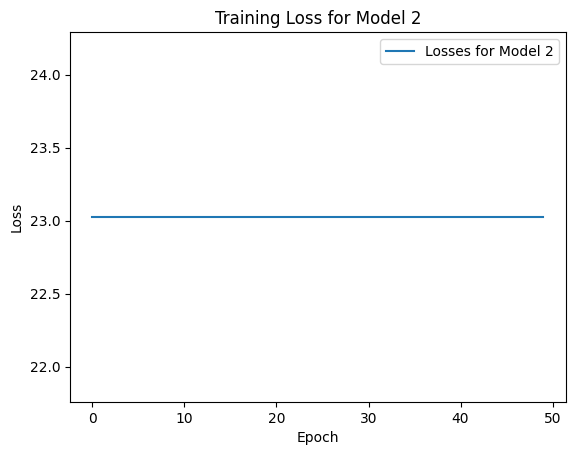

In [13]:
data2 = generate_data(ground_truth_2, N, seqlen, tile_size, batch_size)
model2 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q2_init = model2.getQ()
m2_init = model2.getM()

losses2 = model2.train(data2, lr=0.01, epochs=50)

# plot losses2
plt.plot(losses2, label='Losses for Model 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 2')
plt.legend()
plt.show()

In [14]:
print(Q2_init.numpy())
print()
print(m2_init.numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [15]:
print(model2.getQ().numpy())
print()
print(model2.getM().numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [16]:
print(ground_truth_2)

[0.1 0.2 0.3 0.4]


---

2025-06-12 15:45:33,671 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 15:45:33,685 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 1), m_logit shape: (1,)
2025-06-12 15:45:33,694 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 15:45:34.190693: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:34,193 - INFO - [background_model.train] >>> epoch     0 mean loss = 23.0259, time: 0.50s
2025-06-12 15:45:34.355341: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:34.508486: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 15:45:34.669976: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


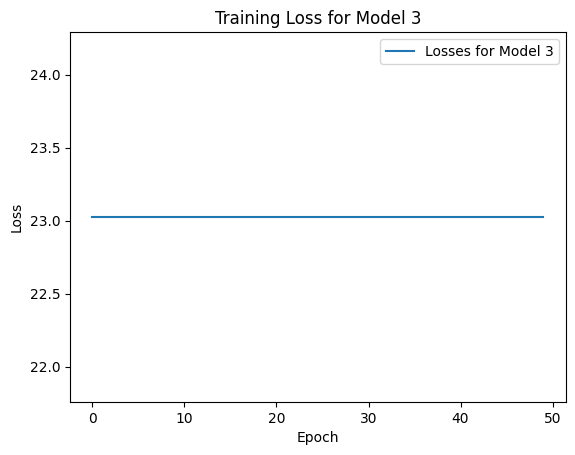

In [17]:
data3 = generate_data(ground_truth_3, N, seqlen, tile_size, batch_size)
model3 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q3_init = model3.getQ()
m3_init = model3.getM()

losses3 = model3.train(data3, lr=0.01, epochs=50)

# plot losses3
plt.plot(losses3, label='Losses for Model 3')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 3')
plt.legend()
plt.show()

In [18]:
print(Q3_init.numpy())
print()
print(m3_init.numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [19]:
print(model3.getQ().numpy())
print()
print(model3.getM().numpy())

[[0.2593]
 [0.248 ]
 [0.2436]
 [0.2491]]

[1.]


In [20]:
print(ground_truth_3)

[0.1 0.4 0.4 0.1]
